# PTB-DB Generalization Test

Validates that the Adam-based pipeline generalizes beyond MIT-BIH to a
different ECG classification task (binary: Healthy vs Myocardial Infarction).

Dataset: PTB Diagnostic ECG Database (14,552 samples)
Task: Binary classification — retrain the head (final Dense layer only)
or train from scratch to verify pipeline flexibility.

In [1]:
import sys, os
from pathlib import Path
_r = Path.cwd()
while not (_r / 'src').is_dir():
    _r = _r.parent
os.chdir(_r)
if str(_r) not in sys.path:
    sys.path.insert(0, str(_r))

from src.data.loader import load_ptbdb
from src.data.preprocessor import preprocess
from src.models.resnet1d import ResNet1D
from src.training.trainer import Trainer
from src.optimizers.optimizer_factory import build_optimizer
from src.utils.seed import set_seed
from src.utils.device import get_device

In [2]:
set_seed(42)
device = get_device()
X, y = load_ptbdb()
print(f'PTB-DB: {X.shape}, classes: {set(y)}')

Using GPU: NVIDIA GeForce RTX 4070 Laptop GPU
PTB-DB: (14552, 187), classes: {0, 1}


/home/infinity/Documents/GitHub/CardioSense/src/data/loader.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_normal["label"] = 0
/home/infinity/Documents/GitHub/CardioSense/src/data/loader.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_abnormal["label"] = 1


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from src.data.preprocessor import preprocess
from src.data.dataset import build_dataloaders

# Split PTB-DB into train/test (80/20 stratified) — no pre-split CSV exists
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train_raw.shape} | Test: {X_test_raw.shape}')
print(f'Class balance — 0=Healthy, 1=MI')
for cls, cnt in zip(*np.unique(y_train_raw, return_counts=True)):
    print(f'  Train class {cls}: {cnt} ({cnt/len(y_train_raw):.1%})')

# Full preprocessing pipeline: normalize + IQR outlier removal + SMOTE (train only)
splits = preprocess(X_train_raw, y_train_raw, X_test_raw, y_test_raw, val_fraction=0.15)
train_loader, val_loader, test_loader = build_dataloaders(splits, batch_size=128)
print(f'\nBatches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')

Train: (11641, 187) | Test: (2911, 187)
Class balance — 0=Healthy, 1=MI
  Train class 0: 3237 (27.8%)
  Train class 1: 8404 (72.2%)

Batches — train: 112, val: 14, test: 23


In [4]:
from src.models.resnet1d import ResNet1D
from src.training.focal_loss import FocalLoss, compute_class_frequencies
from src.training.callbacks import EarlyStopping, ModelCheckpoint

model = ResNet1D(num_classes=2)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# Use pre-SMOTE y_train_raw: post-SMOTE gives equal classes → uniform alpha, defeating class weighting
class_freqs = compute_class_frequencies(y_train_raw, num_classes=2)
loss_fn = FocalLoss(gamma=2.0, class_frequencies=class_freqs)
optimizer = build_optimizer(model, 'adam')

callbacks = [
    EarlyStopping(patience=15),
    ModelCheckpoint(model_name='resnet1d_ptbdb', optimizer_name='adam'),
]

trainer = Trainer(model, optimizer, loss_fn, device, callbacks=callbacks, max_epochs=50)
history = trainer.fit(train_loader, val_loader)

Parameters: 789,794


Epoch   1/50 | loss 0.0502/0.0329 | f1 0.9023/0.9335 | 1.5s


Epoch   2/50 | loss 0.0244/0.0596 | f1 0.9551/0.8705 | 1.0s


Epoch   3/50 | loss 0.0142/0.0292 | f1 0.9754/0.9534 | 1.0s


Epoch   4/50 | loss 0.0119/0.0146 | f1 0.9810/0.9782 | 1.0s


...

Epoch  35/50 | loss 0.0001/0.0111 | f1 1.0000/0.9943 | 1.0s


Epoch  36/50 | loss 0.0000/0.0136 | f1 1.0000/0.9914 | 1.0s


Epoch  37/50 | loss 0.0000/0.0125 | f1 1.0000/0.9943 | 1.0s


Epoch  38/50 | loss 0.0001/0.0135 | f1 0.9999/0.9914 | 1.0s


Epoch  39/50 | loss 0.0000/0.0132 | f1 1.0000/0.9914 | 1.0s
Early stopping at epoch 39.


Accuracy : 0.9928
Macro F1 : 0.9910
Mean AUC : 0.9988
Per-class F1 — Healthy: 0.9870  |  MI: 0.9950


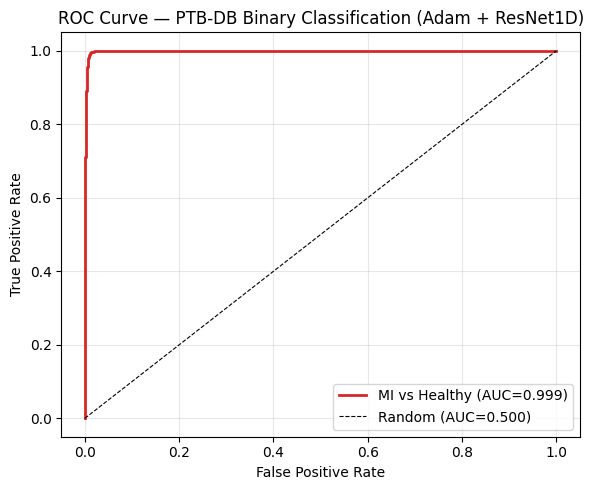

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from src.evaluation.metrics import compute_metrics, get_predictions

y_true, y_pred, y_prob = get_predictions(model, test_loader, device)
results = compute_metrics(y_true, y_pred, y_prob, num_classes=2)

print(f'Accuracy : {results.accuracy:.4f}')
print(f'Macro F1 : {results.macro_f1:.4f}')
print(f'Mean AUC : {results.mean_roc_auc:.4f}')
print(f'Per-class F1 — Healthy: {results.per_class_f1[0]:.4f}  |  MI: {results.per_class_f1[1]:.4f}')

# Binary ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color='#d62728', linewidth=2, label=f'MI vs Healthy (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.500)')
ax.set_title('ROC Curve — PTB-DB Binary Classification (Adam + ResNet1D)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/plots/ptbdb_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()